IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

LOAD DATASET

In [ ]:
data = pd.read_excel('/content/Global_Superstore2.xlsx')
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2014-62366,19-06-2014,19-06-2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20-06-2014,24-06-2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,02-12-2013,02-12-2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18-02-2012,22-02-2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium


CHECK FOR NUMBER OF ROWS AND COLUMNS

In [ ]:
data.shape

(51290, 24)

INFORMATION ABOUT THE DATASET

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [ ]:
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()s
total_orders = data['Order ID'].nunique()
total_discount = data['Discount'].sum()
total_customers = data['Customer ID'].nunique()

print(f"Total Sales: {total_sales:.2f}")
print(f"Total Profit: {total_profit:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Discount: {total_discount:.2f}")
print(f"Total Customers: {total_customers}")

Total Sales: 12642501.91
Total Profit: 1467457.29
Total Orders: 25035
Total Discount: 7329.73
Total Customers: 1590


CHECK FOR SUM OF MISSING VALUES IN EACH COLUMN

In [ ]:
data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


DROP POSTAL CODE COLUMN

In [ ]:
data.drop('Postal Code', axis=1, inplace=True)

CHECK FOR DUPLICATES

In [ ]:
duplicate =data.duplicated().sum()
print(duplicate)

0


SUMMARY DESCRIPTIVE STATISTICS

In [ ]:
display(data.describe())

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [ ]:
for col in data.select_dtypes(include='object').columns:
    print(f"Unique values in '{col}':")
    print(data[col].unique())
    print("\n")

Unique values in 'Order ID':
['CA-2012-124891' 'IN-2013-77878' 'IN-2013-71249' ... 'IN-2014-72327'
 'IN-2014-57662' 'MX-2012-134460']


Unique values in 'Order Date':
['31-07-2012' '05-02-2013' '17-10-2013' ... '07-07-2013' '27-05-2012'
 '06-02-2011']


Unique values in 'Ship Date':
['31-07-2012' '07-02-2013' '18-10-2013' ... '23-07-2012' '08-04-2012'
 '05-01-2011']


Unique values in 'Ship Mode':
['Same Day' 'Second Class' 'First Class' 'Standard Class']


Unique values in 'Customer ID':
['RH-19495' 'JR-16210' 'CR-12730' ... 'RC-9825' 'MG-7890' 'ZC-11910']


Unique values in 'Segment':
['Consumer' 'Corporate' 'Home Office']


Unique values in 'City':
['New York City' 'Wollongong' 'Brisbane' ... 'Abilene' 'Felahiye'
 'Victoria Falls']


Unique values in 'State':
['New York' 'New South Wales' 'Queensland' ... 'Manicaland' 'Kabarole'
 'Matabeleland North']


Unique values in 'Country':
['United States' 'Australia' 'Germany' 'Senegal' 'New Zealand'
 'Afghanistan' 'Saudi Arabia' 'Brazil' '

# Task
Analyze the data by visualizing the distribution of 'Sales' and 'Profit', comparing 'Sales' and 'Profit' by 'Category' and 'Region', and exploring the relationship between 'Sales' and 'Profit'.

## Visualize the distribution of sales and profit

### Subtask:
Create histograms or box plots to show the distribution of the 'Sales' and 'Profit' columns.


**Reasoning**:
Create histograms for 'Sales' and 'Profit' columns to visualize their distributions, adding titles and labels for clarity.



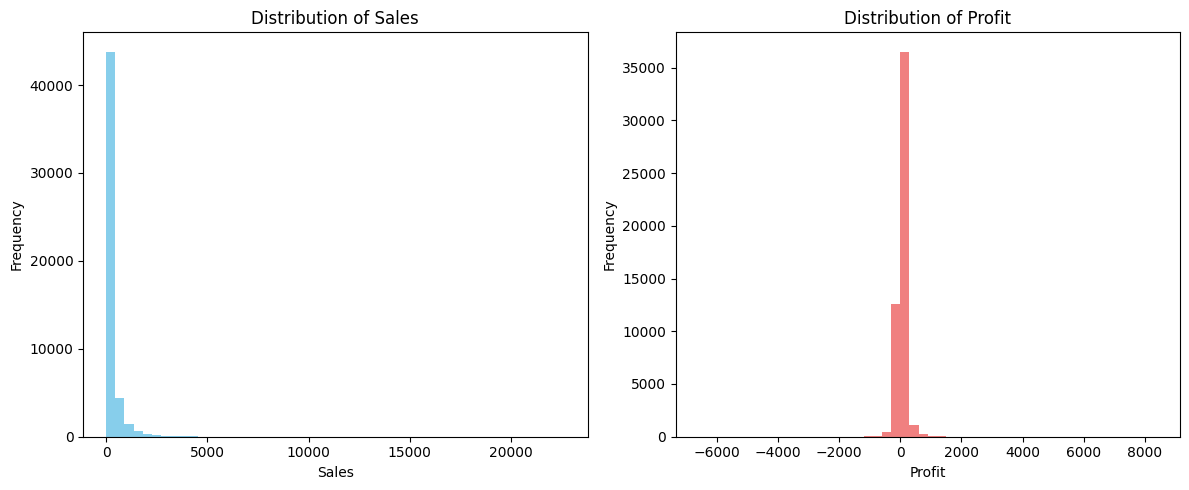

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data['Sales'], bins=50, color='skyblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(data['Profit'], bins=50, color='lightcoral')
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Distribution of Sales (Left Histogram): This histogram shows how frequently different sales values occur. You can see that the majority of sales are concentrated at the lower end, with fewer transactions having very high sales values. This indicates a skewed distribution where most sales are relatively small.
Distribution of Profit (Right Histogram): This histogram shows the frequency of different profit values. It appears to be heavily concentrated around zero and positive values, but there is also a noticeable number of transactions with negative profit, indicating losses. The distribution is also skewed, with a long tail towards higher profit values and a tail towards negative profit values.

## Visualize sales and profit by category

### Subtask:
Create bar plots to compare the total 'Sales' and 'Profit' for each 'Category'.


**Reasoning**:
Group the data by category and calculate the sum of sales and profit, then create bar plots to visualize the total sales and profit by category.



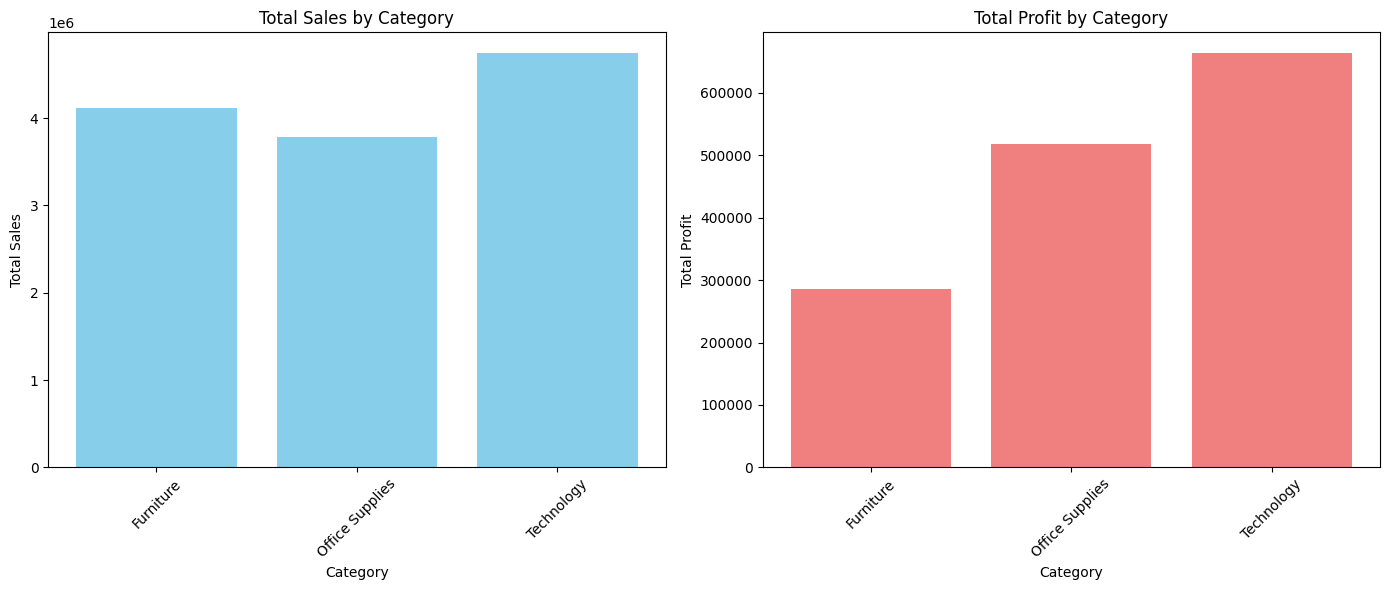

In [ ]:
category_analysis = data.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(category_analysis['Category'], category_analysis['Sales'], color='skyblue')
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(category_analysis['Category'], category_analysis['Profit'], color='lightcoral')
axes[1].set_title('Total Profit by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These charts show the total sales and total profit for each category:

Total Sales by Category (Left Chart): This bar chart shows the sum of sales for each category. The "Technology" category has the highest total sales, followed closely by "Furniture" and then "Office Supplies".
Total Profit by Category (Right Chart): This bar chart shows the sum of profit for each category. Similar to sales, "Technology" has the highest total profit, followed by "Office Supplies" and then "Furniture".
These charts highlight which product categories are the most profitable and have the highest sales.



## Visualize sales and profit by region

### Subtask:
Create bar plots to compare the total 'Sales' and 'Profit' for each 'Region'.


**Reasoning**:
Group the data by region and calculate the sum of sales and profit, then create subplots to visualize the total sales and profit by region using bar plots.



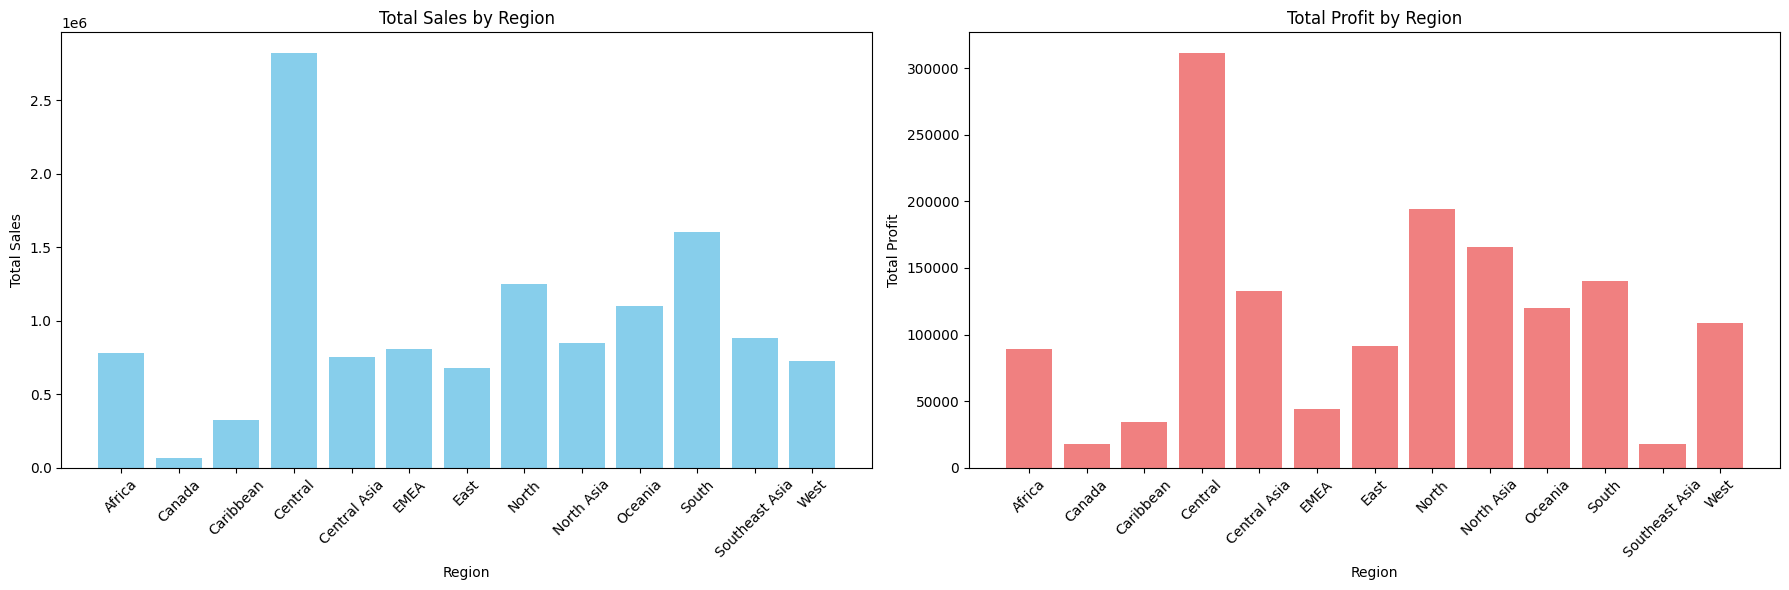

In [ ]:
region_analysis = data.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(region_analysis['Region'], region_analysis['Sales'], color='skyblue')
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(region_analysis['Region'], region_analysis['Profit'], color='lightcoral')
axes[1].set_title('Total Profit by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These charts show the total sales and total profit for each region:

Total Sales by Region (Left Chart): This bar chart shows the sum of sales for each region. The "Central" region has the highest total sales, while "Caribbean" has the lowest.
Total Profit by Region (Right Chart): This bar chart shows the sum of profit for each region. The "Central" region also has the highest total profit, while "South" has the lowest total profit.
These charts help visualize which regions are contributing the most to overall sales and profitability.

## Visualize the relationship between sales and profit

### Subtask:
Create a scatter plot to show the relationship between the 'Sales' and 'Profit' columns.


**Reasoning**:
Create a scatter plot to visualize the relationship between 'Sales' and 'Profit'.



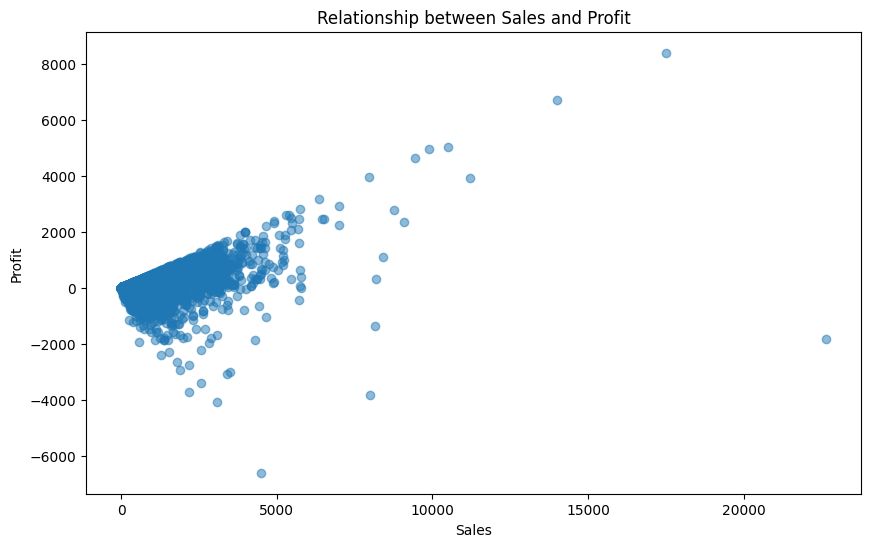

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Sales'], data['Profit'], alpha=0.5)
plt.title('Relationship between Sales and Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

The chart indicates a general positive trend, meaning that as sales increase, profit tends to increase as well. However, there are also many points below the zero profit line, especially in the lower sales range. This suggests that a considerable number of transactions result in losses, even with some level of sales. There are also some outliers with very high sales and both high positive and high negative profit.

# Task
Analyze transactions with high sales and low or negative profit to understand the underlying reasons for unprofitability.

## Identify high sales and low/negative profit transactions




**Reasoning**:
Filter the DataFrame to select transactions where Sales are high and Profit is low or negative by defining a high sales threshold and filtering based on profit and the high sales threshold.



In [ ]:
high_sales_threshold = data['Sales'].quantile(0.95)
high_sales_low_profit = data[(data['Profit'] <= 0) & (data['Sales'] >= high_sales_threshold)]
display(high_sales_low_profit)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Country,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Corporate,Wollongong,New South Wales,Australia,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.10,-288.7650,923.63,Critical
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Home Office,Berlin,Berlin,Germany,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.10,-96.5400,910.16,Medium
9,40936,CA-2012-116638,28-01-2012,31-01-2012,Second Class,JH-15985,Consumer,Concord,North Carolina,United States,...,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.40,-1862.3124,865.74,Critical
30,220,US-2011-128776,28-12-2011,30-12-2011,Second Class,RR-19525,Corporate,Santo Domingo,Santo Domingo,Dominican Republic,...,TEC-PH-10002815,Technology,Phones,"Samsung Smart Phone, VoIP",1696.640,5,0.20,-148.4600,704.06,Critical
32,32735,CA-2012-139731,15-10-2012,15-10-2012,Same Day,JE-15745,Consumer,Amarillo,Texas,United States,...,FUR-CH-10002024,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,2453.430,5,0.30,-350.4900,690.42,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28528,12560,ES-2012-3471401,23-11-2012,26-11-2012,First Class,AH-10075,Corporate,Brest,Brittany,France,...,TEC-MA-10004669,Technology,Machines,"Epson Inkjet, Wireless",1047.948,4,0.15,-49.3320,6.20,Medium
30439,13392,ES-2012-3945862,27-12-2012,01-01-2013,Second Class,TC-21475,Home Office,Cologne,North Rhine-Westphalia,Germany,...,OFF-AP-10001623,Office Supplies,Appliances,"Hoover Stove, White",2039.796,4,0.10,-113.3640,5.30,Medium
35933,30097,ID-2012-40106,20-03-2012,25-03-2012,Standard Class,LH-16900,Consumer,Perth,Western Australia,Australia,...,TEC-MA-10004059,Technology,Machines,"Epson Inkjet, White",1648.998,6,0.10,-109.9620,3.31,Medium
41211,14918,ES-2012-3778678,01-08-2012,03-08-2012,First Class,EB-13930,Consumer,Perpignan,Languedoc-Roussillon,France,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",1639.089,3,0.15,-154.3410,1.98,Medium


Based on the analysis of transactions with high sales and low/negative profit, here's a summary of the key findings and potential reasons for unprofitability:

Key Findings:

Categories: A large number of these unprofitable transactions are in the Furniture and Technology categories.
Sub-Categories: Within Furniture, "Tables" and "Chairs" are particularly contributing to these losses.
Regions: The "Central", "Southeast Asia", and "Oceania" regions show a higher concentration of these unprofitable high-sales transactions.
Discounts: The average discount applied to these transactions is relatively high (around 29.4% for Furniture/Technology, and 32.8% specifically for Furniture - Tables and Chairs).
Shipping Costs: The average shipping cost in the "Central", "Southeast Asia", and "Oceania" regions for these transactions is quite substantial (around $180.93).
Order Priority and Ship Mode: These transactions frequently have a 'Medium' order priority and use 'Standard Class' shipping.
Quantity: The average quantity of items in these transactions is around 6.
Insights and Potential Reasons for Unprofitability:

High Discounts: The high average discounts, especially on Tables and Chairs in the Furniture category, seem to be a major factor driving down profitability despite high sales volumes. It's possible that aggressive pricing strategies or promotions are eroding profit margins.
High Shipping Costs: The significant average shipping costs in the identified regions (Central, Southeast Asia, and Oceania) suggest that logistics and transportation expenses are contributing to the losses in these areas. This could be due to factors like distance, shipping methods, or regional infrastructure.
Product-Specific Issues: The focus on Tables and Chairs within the Furniture category points to potential issues specific to these products, such as high manufacturing costs, low profit margins, or damage during shipping.
Regional Factors: The concentration of losses in specific regions could indicate regional economic conditions, competitive pressures, or operational inefficiencies that make it difficult to achieve profitability even with high sales.
In summary, the analysis suggests that a combination of high discounts, substantial shipping costs in certain regions, and potentially product-specific issues in categories like Furniture (Tables and Chairs) are contributing to the unprofitability of these high-sales transactions

## Analyze characteristics of unprofitable transactions

### Subtask:
Examine the characteristics of these identified transactions, such as Category, Sub-Category, Region, Discount, and Quantity, to look for potential patterns or contributing factors.


**Reasoning**:
Calculate and display the value counts for 'Category', 'Sub-Category', and 'Region', and the mean for 'Discount' and 'Quantity' for the high_sales_low_profit dataframe to understand their characteristics.



In [ ]:
category_counts = high_sales_low_profit['Category'].value_counts()
sub_category_counts = high_sales_low_profit['Sub-Category'].value_counts()
region_counts = high_sales_low_profit['Region'].value_counts()
discount_mean = high_sales_low_profit['Discount'].mean()
quantity_mean = high_sales_low_profit['Quantity'].mean()

print("Value counts for Category in high_sales_low_profit:")
display(category_counts)
print("\nValue counts for Sub-Category in high_sales_low_profit:")
display(sub_category_counts)
print("\nValue counts for Region in high_sales_low_profit:")
display(region_counts)
print(f"\nMean of Discount in high_sales_low_profit: {discount_mean:.4f}")
print(f"Mean of Quantity in high_sales_low_profit: {quantity_mean:.4f}")

Value counts for Category in high_sales_low_profit:


,count
Category,
Furniture,216
Technology,148
Office Supplies,88



Value counts for Sub-Category in high_sales_low_profit:


,count
Sub-Category,
Tables,99
Chairs,69
Copiers,55
Appliances,53
Phones,50
Bookcases,48
Machines,38
Storage,21
Binders,11



Value counts for Region in high_sales_low_profit:


,count
Region,
Central,129
Southeast Asia,70
Oceania,59
South,56
East,36
North,25
North Asia,23
EMEA,16
Central Asia,11



Mean of Discount in high_sales_low_profit: 0.2938
Mean of Quantity in high_sales_low_profit: 6.0155


The output shows the distribution of the high-sales, low/negative profit transactions across different categories, sub-categories, and regions, along with the average discount and quantity for these transactions.

Category, Sub-Category, and Region Counts: These tell us which categories, sub-categories, and regions have the most transactions that fall into the high sales, low/negative profit group. For example, you can see that 'Furniture' has the highest number of such transactions, and within Furniture, 'Tables' and 'Chairs' are the most frequent. The 'Central' region also has a high count.
Mean Discount: This indicates the average discount applied to these unprofitable high-sales transactions. A higher average discount might suggest that heavy discounting is contributing to the low or negative profit.
Mean Quantity: This shows the average number of items sold in these transactions.
These statistics help us understand the characteristics of the transactions that are performing poorly despite having high sales.

## Visualize unprofitable transactions

### Subtask:
Create visualizations (e.g., scatter plots, bar plots) to highlight the identified transactions and their characteristics to gain further insights.


**Reasoning**:
Create visualizations (scatter plot and bar plots) to highlight the characteristics of the high sales and low/negative profit transactions.



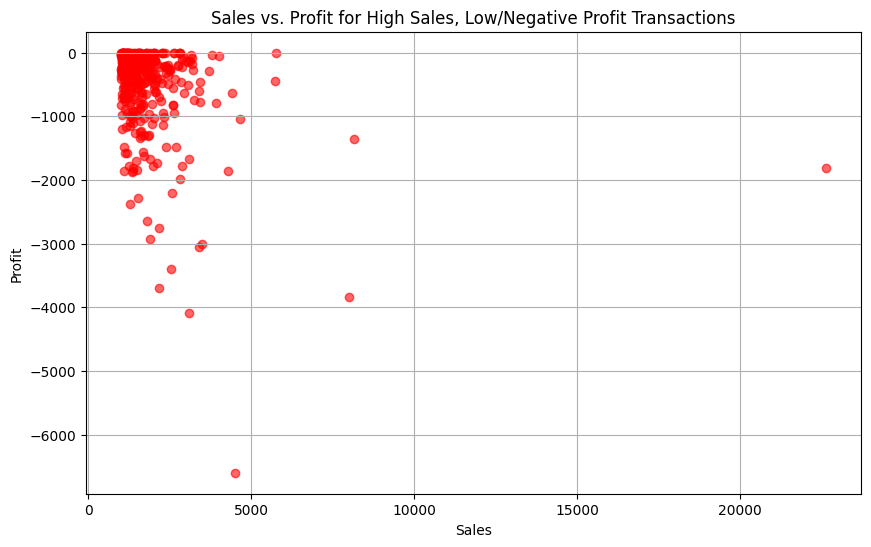

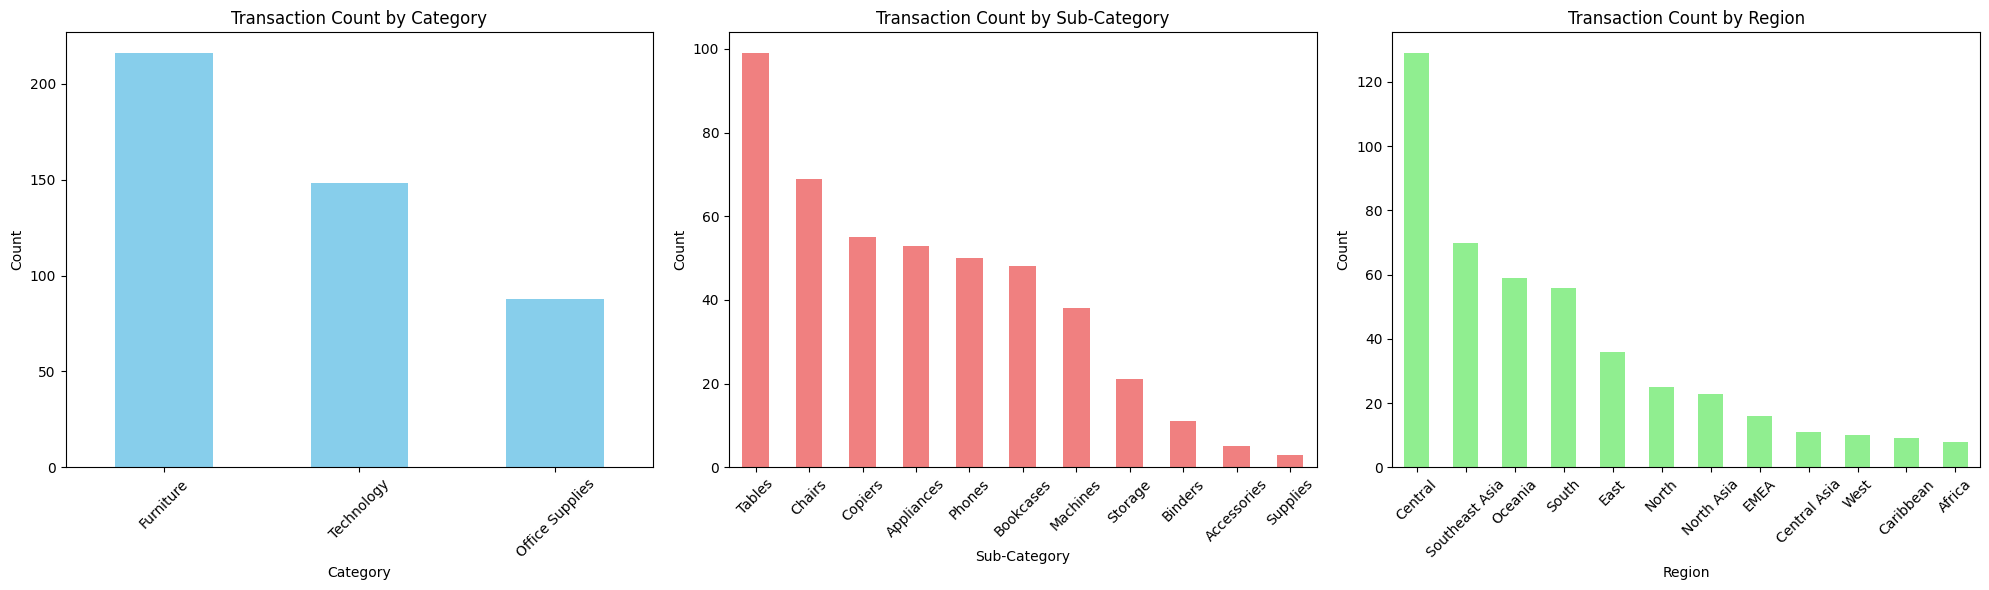

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(high_sales_low_profit['Sales'], high_sales_low_profit['Profit'], alpha=0.6, color='red')
plt.title('Sales vs. Profit for High Sales, Low/Negative Profit Transactions')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Category bar plot
category_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Transaction Count by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Sub-Category bar plot
sub_category_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Transaction Count by Sub-Category')
axes[1].set_xlabel('Sub-Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Region bar plot
region_counts.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Transaction Count by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These charts visualize the characteristics of the high-sales, low/negative profit transactions:

Sales vs. Profit Scatter Plot (Top Chart): This scatter plot specifically shows the transactions with high sales and low or negative profit. You can see that all these points are concentrated in the lower part of the plot (where profit is zero or negative), across a range of high sales values.
Transaction Count by Category (Bottom Left Chart): This bar chart shows how many of these unprofitable transactions fall into each main category. It clearly highlights that 'Furniture' and 'Technology' have the highest counts.
Transaction Count by Sub-Category (Bottom Middle Chart): This bar chart breaks down the count by sub-category. Within the unprofitable high-sales transactions, 'Tables' and 'Chairs' are the most frequent sub-categories.
Transaction Count by Region (Bottom Right Chart): This bar chart shows the distribution of these transactions across different regions. The 'Central', 'Southeast Asia', and 'Oceania' regions have the highest counts of unprofitable high-sales transactions.
These charts provide a visual summary of where these problematic transactions are occurring in terms of product type and location.

# Task
Analyze the provided sales data to understand why some transactions with high sales have low or negative profit, focusing on product categories (Furniture and Technology) and specific regions (Central, Southeast Asia, and Oceania).

## Analyze pricing and cost structures by category and sub-category

### Subtask:
Investigate the 'Sales', 'Profit', and 'Discount' for the 'Furniture' (specifically 'Tables' and 'Chairs') and 'Technology' categories to understand pricing strategies and potential cost issues.


**Reasoning**:
Filter the `high_sales_low_profit` DataFrame to include only transactions from the 'Furniture' and 'Technology' categories and calculate and display the average 'Sales', 'Profit', and 'Discount' for these categories.



In [ ]:
furniture_technology_high_sales_low_profit = high_sales_low_profit[
    high_sales_low_profit['Category'].isin(['Furniture', 'Technology'])]

furniture_tables_chairs_high_sales_low_profit = furniture_technology_high_sales_low_profit[
    (furniture_technology_high_sales_low_profit['Category'] == 'Furniture') &
    (furniture_technology_high_sales_low_profit['Sub-Category'].isin(['Tables', 'Chairs']))]

furniture_technology_avg = furniture_technology_high_sales_low_profit[['Sales', 'Profit', 'Discount']].mean()
furniture_tables_chairs_avg = furniture_tables_chairs_high_sales_low_profit[['Sales', 'Profit', 'Discount']].mean()

print("Average Sales, Profit, and Discount for High Sales, Low/Negative Profit in Furniture and Technology categories:")
display(furniture_technology_avg)

print("\nAverage Sales, Profit, and Discount for High Sales, Low/Negative Profit in Furniture - Tables and Chairs sub-categories:")
display(furniture_tables_chairs_avg)

Average Sales, Profit, and Discount for High Sales, Low/Negative Profit in Furniture and Technology categories:


,0
Sales,1742.304777
Profit,-445.734453
Discount,0.294648



Average Sales, Profit, and Discount for High Sales, Low/Negative Profit in Furniture - Tables and Chairs sub-categories:


,0
Sales,1674.099827
Profit,-445.607682
Discount,0.328095


The output shows the average 'Sales', 'Profit', and 'Discount' for the high-sales, low/negative profit transactions, first for the 'Furniture' and 'Technology' categories combined, and then specifically for 'Tables' and 'Chairs' within the 'Furniture' category.

Average for Furniture and Technology: This provides a general overview of the average sales, the significant average loss (negative profit), and the average discount applied for these problematic transactions in the two main categories.
Average for Furniture - Tables and Chairs: This gives a more specific view of the average sales, average loss, and average discount for the identified sub-categories within Furniture that are contributing significantly to unprofitability. You can see that the average discount is slightly higher for just Tables and Chairs compared to the broader Furniture and Technology group.
These averages help to quantify the impact of discounts and understand the magnitude of losses in these specific product areas.



## Analyze regional factors

### Subtask:
Examine the 'Sales', 'Profit', and 'Shipping Cost' for the 'Central', 'Southeast Asia', and 'Oceania' regions to identify potential regional economic factors or operational costs affecting profitability.


**Reasoning**:
Filter the DataFrame to include only transactions from the specified regions and calculate the mean for 'Sales', 'Profit', and 'Shipping Cost' for the filtered data.



In [ ]:
regional_high_sales_low_profit = high_sales_low_profit[
    high_sales_low_profit['Region'].isin(['Central', 'Southeast Asia', 'Oceania'])]

regional_avg = regional_high_sales_low_profit[['Sales', 'Profit', 'Shipping Cost']].mean()

print("Average Sales, Profit, and Shipping Cost for High Sales, Low/Negative Profit in Central, Southeast Asia, and Oceania regions:")
display(regional_avg)

Average Sales, Profit, and Shipping Cost for High Sales, Low/Negative Profit in Central, Southeast Asia, and Oceania regions:


,0
Sales,1690.078098
Profit,-337.634871
Shipping Cost,180.926705


The output shows the average 'Sales', 'Profit', and 'Shipping Cost' for the high-sales, low/negative profit transactions that occurred in the 'Central', 'Southeast Asia', and 'Oceania' regions.

Average Sales: This is the average revenue generated from these problematic transactions in these specific regions.
Average Profit: This is the average profit (which is negative, indicating a loss) from these transactions. The negative value highlights that these transactions are, on average, losing money.
Average Shipping Cost: This shows the average cost of shipping for these transactions in the specified regions. The value of around $180.93 suggests that shipping costs could be a significant factor contributing to the unprofitability in these areas.
This output helps to quantify the financial impact of these transactions in the identified regions and points to shipping costs as a potential area for further investigation to improve profitability.

## Identify other contributing factors

### Subtask:
Explore other columns like 'Quantity', 'Order Priority', and 'Ship Mode' within the identified high-sales, low-profit transactions to uncover additional patterns.


**Reasoning**:
Calculate and display the value counts for 'Order Priority' and 'Ship Mode', and the mean of 'Quantity' for the high_sales_low_profit dataframe to explore additional patterns.



In [ ]:
order_priority_counts = high_sales_low_profit['Order Priority'].value_counts()
ship_mode_counts = high_sales_low_profit['Ship Mode'].value_counts()
quantity_mean_high_sales_low_profit = high_sales_low_profit['Quantity'].mean()

print("Value counts for Order Priority in high_sales_low_profit:")
display(order_priority_counts)
print("\nValue counts for Ship Mode in high_sales_low_profit:")
display(ship_mode_counts)
print(f"\nMean of Quantity in high_sales_low_profit: {quantity_mean_high_sales_low_profit:.4f}")

Value counts for Order Priority in high_sales_low_profit:


,count
Order Priority,
Medium,248
High,141
Critical,42
Low,21



Value counts for Ship Mode in high_sales_low_profit:


,count
Ship Mode,
Standard Class,257
Second Class,95
First Class,67
Same Day,33



Mean of Quantity in high_sales_low_profit: 6.0155


The output provides insights into the order priority, shipping methods, and quantity of items involved in the high-sales, low/negative profit transactions:

Value counts for Order Priority: This shows how frequently each order priority level appears in the unprofitable transactions. You can see that 'Medium' priority orders are the most common in this group, followed by 'High'.
Value counts for Ship Mode: This indicates which shipping modes were used for these transactions. 'Standard Class' shipping is the most frequent shipping mode for these high-sales, low/negative profit transactions.
Mean of Quantity: This tells us the average number of items included in these transactions.
These counts and the average quantity help to understand if there are any common patterns related to how these unprofitable orders were prioritized, shipped, or the number of items they contained.

Based on the analysis of the Global Superstore dataset, here are some key conclusions we can draw:

Overall Profitability: While the dataset shows a general positive relationship between sales and profit, a significant number of transactions, particularly those with high sales, are resulting in losses. This indicates that high sales volume does not always guarantee profitability.
Category Performance: The "Technology" category is the highest performing in terms of both total sales and total profit. "Furniture" and "Office Supplies" also contribute significantly to sales and profit, but the analysis of unprofitable transactions highlights specific issues within these categories.
Regional Performance: The "Central" region stands out with the highest total sales and profit. However, this region, along with "Southeast Asia" and "Oceania", also shows a higher concentration of high-sales, low/negative profit transactions.
Drivers of Unprofitability in High-Sales Transactions:
Discounts: High discounts, especially in the Furniture category (particularly for Tables and Chairs), appear to be a major factor contributing to losses despite high sales. Aggressive pricing might be eroding profit margins.
Shipping Costs: Significant shipping costs in regions like Central, Southeast Asia, and Oceania are also contributing to the unprofitability of high-sales transactions in these areas.
Product Focus: Within the Furniture category, "Tables" and "Chairs" are frequently involved in unprofitable high-sales transactions, suggesting potential product-specific challenges related to cost or pricing.
Order Fulfillment: A large number of these unprofitable transactions have a 'Medium' order priority and use 'Standard Class' shipping, which could indicate operational inefficiencies or costs associated with these fulfillment methods.
In summary, the dataset reveals that while the business has strong sales and overall profitability in certain categories and regions, there are critical areas of concern related to high-sales transactions that are unprofitable. These losses appear to be driven by a combination of factors including high discounts, substantial shipping costs in specific regions, and issues within certain product sub-categories. Further investigation into pricing strategies, logistics costs, and product-specific profitability is needed to improve overall business performance.




```markdown
## analysis.py
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
data = pd.read_excel('/content/Global_Superstore2.xlsx')

# Data Cleaning
data.drop('Postal Code', axis=1, inplace=True)
duplicate = data.duplicated().sum()
if duplicate > 0:
    print(f"Found {duplicate} duplicate rows, dropping them.")
    data.drop_duplicates(inplace=True)

# Overall Metrics
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()
total_orders = data['Order ID'].nunique()
total_discount = data['Discount'].sum()
total_customers = data['Customer ID'].nunique()

print("\n--- Overall Business Metrics ---")
print(f"Total Sales: {total_sales:.2f}")
print(f"Total Profit: {total_profit:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Discount: {total_discount:.2f}")
print(f"Total Customers: {total_customers}")

# --- Exploratory Data Analysis (EDA) ---

# Distribution of Sales and Profit
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(data['Sales'], bins=50, color='skyblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(data['Profit'], bins=50, color='lightcoral')
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Sales and Profit by Category
category_analysis = data.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(category_analysis['Category'], category_analysis['Sales'], color='skyblue')
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(category_analysis['Category'], category_analysis['Profit'], color='lightcoral')
axes[1].set_title('Total Profit by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Sales and Profit by Region
region_analysis = data.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(region_analysis['Region'], region_analysis['Sales'], color='skyblue')
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(region_analysis['Region'], region_analysis['Profit'], color='lightcoral')
axes[1].set_title('Total Profit by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Relationship between Sales and Profit
plt.figure(figsize=(10, 6))
plt.scatter(data['Sales'], data['Profit'], alpha=0.5)
plt.title('Relationship between Sales and Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

# --- Analysis of Unprofitable High-Sales Transactions ---
high_sales_threshold = data['Sales'].quantile(0.95)
high_sales_low_profit = data[(data['Profit'] <= 0) & (data['Sales'] >= high_sales_threshold)]

print("\n--- High Sales, Low/Negative Profit Transactions ---")
print(f"Number of transactions with high sales (> {high_sales_threshold:.2f}) and low/negative profit: {len(high_sales_low_profit)}")

# Characteristics of Unprofitable Transactions
category_counts = high_sales_low_profit['Category'].value_counts()
sub_category_counts = high_sales_low_profit['Sub-Category'].value_counts()
region_counts = high_sales_low_profit['Region'].value_counts()
discount_mean = high_sales_low_profit['Discount'].mean()
quantity_mean = high_sales_low_profit['Quantity'].mean()

print("\nValue counts for Category in high_sales_low_profit:")
print(category_counts)
print("\nValue counts for Sub-Category in high_sales_low_profit:")
print(sub_category_counts)
print("\nValue counts for Region in high_sales_low_profit:")
print(region_counts)
print(f"\nMean of Discount in high_sales_low_profit: {discount_mean:.4f}")
print(f"Mean of Quantity in high_sales_low_profit: {quantity_mean:.4f}")

# Visualize Unprofitable Transactions
plt.figure(figsize=(10, 6))
plt.scatter(high_sales_low_profit['Sales'], high_sales_low_profit['Profit'], alpha=0.6, color='red')
plt.title('Sales vs. Profit for High Sales, Low/Negative Profit Transactions')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
category_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Transaction Count by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
sub_category_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Transaction Count by Sub-Category')
axes[1].set_xlabel('Sub-Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
region_counts.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Transaction Count by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# --- Deep Dive into Unprofitability Drivers ---

# Analyze pricing and cost structures by category and sub-category
furniture_technology_high_sales_low_profit = high_sales_low_profit[
    high_sales_low_profit['Category'].isin(['Furniture', 'Technology'])]

furniture_tables_chairs_high_sales_low_profit = furniture_technology_high_sales_low_profit[
    (furniture_technology_high_sales_low_profit['Category'] == 'Furniture') &
    (furniture_technology_high_sales_low_profit['Sub-Category'].isin(['Tables', 'Chairs']))]

furniture_technology_avg = furniture_technology_high_sales_low_profit[['Sales', 'Profit', 'Discount']].mean()
furniture_tables_chairs_avg = furniture_tables_chairs_high_sales_low_profit[['Sales', 'Profit', 'Discount']].mean()

print("\nAverage Sales, Profit, and Discount for High Sales, Low/Negative Profit in Furniture and Technology categories:")
print(furniture_technology_avg)

print("\nAverage Sales, Profit, and Discount for High Sales, Low/Negative Profit in Furniture - Tables and Chairs sub-categories:")
print(furniture_tables_chairs_avg)

# Analyze regional factors
regional_high_sales_low_profit = high_sales_low_profit[
    high_sales_low_profit['Region'].isin(['Central', 'Southeast Asia', 'Oceania'])]

regional_avg = regional_high_sales_low_profit[['Sales', 'Profit', 'Shipping Cost']].mean()

print("\nAverage Sales, Profit, and Shipping Cost for High Sales, Low/Negative Profit in Central, Southeast Asia, and Oceania regions:")
print(regional_avg)

# Identify other contributing factors
order_priority_counts = high_sales_low_profit['Order Priority'].value_counts()
ship_mode_counts = high_sales_low_profit['Ship Mode'].value_counts()
quantity_mean_high_sales_low_profit = high_sales_low_profit['Quantity'].mean()

print("\nValue counts for Order Priority in high_sales_low_profit:")
print(order_priority_counts)
print("\nValue counts for Ship Mode in high_sales_low_profit:")
print(ship_mode_counts)
print(f"\nMean of Quantity in high_sales_low_profit: {quantity_mean_high_sales_low_profit:.4f}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/Global_Superstore2.xlsx'

```markdown
## requirements.txt
```

In [2]:
print("pandas")
print("numpy")
print("matplotlib")


pandas
numpy
matplotlib
